In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sakilparvez/best-model-pt/best_model.pt
/kaggle/input/datasets/sakilparvez/clean-toxic-dataset-bengali/clean_toxic_dataset_bengali.csv


In [46]:
import os
import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    hamming_loss,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup
)

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
SEED = 42

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

In [48]:
df = pd.read_csv("/kaggle/input/datasets/sakilparvez/clean-toxic-dataset-bengali/clean_toxic_dataset_bengali.csv")

print(df.shape)

df.head()

(8465, 7)


,text,vulgar,hate,religious,threat,troll,insult
0,প্রধানমন্ত্রী হক সাহেবের ক্ষতি হলে জাতির স্বার...,0,0,0,1,0,0
1,এই মালাউন পবিত্র কুরআনে আগুন দিয়েছে ওর ফাঁসি চাই,0,0,1,0,0,0
2,আগে কুত্তাটাকে নির্বাচক থেকে অপসারণ করতে হবে এ...,0,0,0,0,1,0
3,এই রমজানে ও তুই লোচ্ছামি করতেছিস হারামি শুয়ার ...,1,0,0,0,0,1
4,চোদনার পুত বদনার নাতি সালা জাত ফকিন্নি মাদারটো...,1,0,0,0,0,1


In [49]:
LABEL_COLUMNS = [
    "vulgar",
    "hate",
    "religious",
    "threat",
    "troll",
    "insult"
]

In [50]:
train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42
)

print(train_df.shape)
print(val_df.shape)

(7195, 7)
(1270, 7)


In [51]:
MODEL_NAME = "xlm-roberta-base"

In [52]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [53]:
class ToxicDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_len=128):

        self.texts = dataframe["text"].values

        self.labels = dataframe[LABEL_COLUMNS].values

        self.tokenizer = tokenizer

        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids":
                encoding["input_ids"].flatten(),

            "attention_mask":
                encoding["attention_mask"].flatten(),

            "labels":
                torch.FloatTensor(self.labels[idx])
        }

In [54]:
train_dataset = ToxicDataset(
    train_df,
    tokenizer
)

val_dataset = ToxicDataset(
    val_df,
    tokenizer
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [55]:
class Attention(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):

        weights = torch.softmax(
            self.attn(x),
            dim=1
        )

        context = torch.sum(
            weights * x,
            dim=1
        )

        return context

RoBERTa + BiLSTM Model

In [56]:
class XLMR_BiLSTM_Attention(nn.Module):

    def __init__(self):

        super().__init__()

        self.roberta = AutoModel.from_pretrained(
            MODEL_NAME
        )

        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=256,
            batch_first=True,
            bidirectional=True
        )

        self.attention = Attention(512)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            512,
            6
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state

        lstm_out, _ = self.lstm(
            sequence_output
        )

        attn_out = self.attention(
            lstm_out
        )

        x = self.dropout(attn_out)

        logits = self.fc(x)

        return logits

In [57]:
label_counts = train_df[LABEL_COLUMNS].sum()

weights = len(train_df) / (
    len(LABEL_COLUMNS) * label_counts
)

pos_weight = torch.tensor(
    weights.values,
    dtype=torch.float
)

In [58]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = XLMR_BiLSTM_Attention()

model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLMR_BiLSTM_Attention(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
  

In [59]:
import torch.nn.functional as F

class FocalLoss(nn.Module):

    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits)

        pt = torch.where(
            targets == 1,
            probs,
            1 - probs
        )

        focal = (
            self.alpha *
            (1 - pt) ** self.gamma *
            bce
        )

        return focal.mean()

In [60]:
criterion = FocalLoss(
    alpha=1.0,
    gamma=2.0
)

In [61]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

In [62]:
EPOCHS = 50

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [63]:
def train_epoch(model, loader):

    model.train()

    losses = []

    for batch in tqdm(loader):

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        logits = model(
            input_ids,
            attention_mask
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        scheduler.step()

        losses.append(loss.item())

    return np.mean(losses)

In [64]:
def evaluate(model, loader):

    model.eval()

    losses = []

    preds = []
    targets = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch[
                "input_ids"
            ].to(device)

            attention_mask = batch[
                "attention_mask"
            ].to(device)

            labels = batch[
                "labels"
            ].to(device)

            logits = model(
                input_ids,
                attention_mask
            )

            loss = criterion(
                logits,
                labels
            )

            losses.append(loss.item())

            probs = torch.sigmoid(
                logits
            )

            preds.extend(
                probs.cpu().numpy()
            )

            targets.extend(
                labels.cpu().numpy()
            )

    preds = np.array(preds)

    targets = np.array(targets)

    binary_preds = (
        preds > 0.5
    ).astype(int)

    macro_f1 = f1_score(
        targets,
        binary_preds,
        average="macro"
    )

    return (
        np.mean(losses),
        macro_f1
    )

In [65]:
best_f1 = 0

train_losses = []
val_losses = []
val_f1s = []

for epoch in range(EPOCHS):

    train_loss = train_epoch(
        model,
        train_loader
    )

    val_loss, val_f1 = evaluate(
        model,
        val_loader
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    val_f1s.append(
        val_f1
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Macro F1: {val_f1:.4f}"
    )

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(
            model.state_dict(),
            "best_model.pt"
        )

        print(
            "Best Model Saved"
        )

  0%|          | 0/450 [00:00<?, ?it/s]

Epoch 1/50
Train Loss: 0.1401
Val Loss: 0.1092
Macro F1: 0.3464
Best Model Saved


  0%|          | 0/450 [00:00<?, ?it/s]

Epoch 2/50
Train Loss: 0.1004
Val Loss: 0.0882
Macro F1: 0.6307
Best Model Saved


  0%|          | 0/450 [00:00<?, ?it/s]

...

Epoch 48/50
Train Loss: 0.0003
Val Loss: 0.2795
Macro F1: 0.7529


  0%|          | 0/450 [00:00<?, ?it/s]

Epoch 49/50
Train Loss: 0.0003
Val Loss: 0.2801
Macro F1: 0.7510


  0%|          | 0/450 [00:00<?, ?it/s]

Epoch 50/50
Train Loss: 0.0003
Val Loss: 0.2817
Macro F1: 0.7507


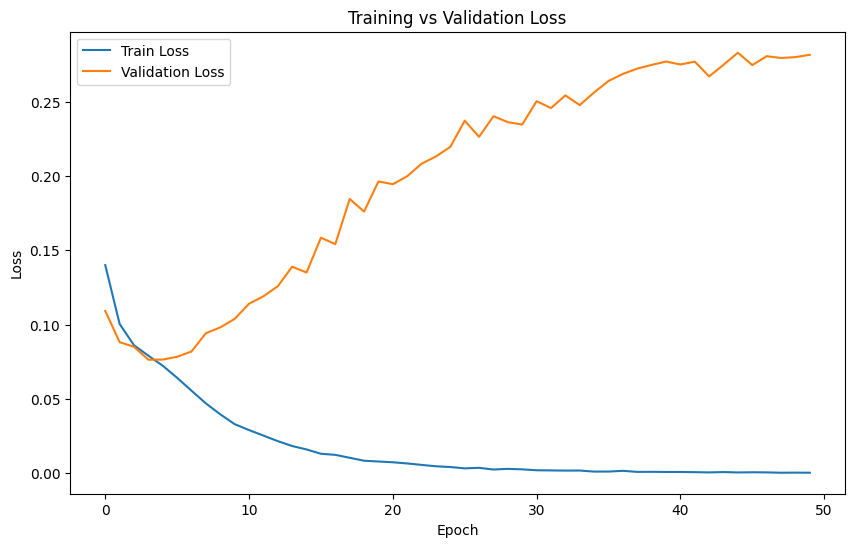

In [66]:
plt.figure(figsize=(10,6))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.show()

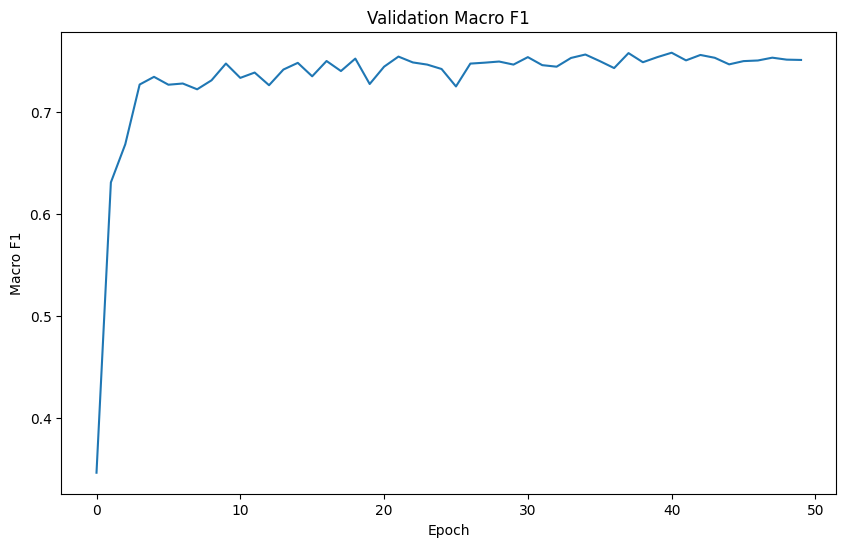

In [67]:
plt.figure(figsize=(10,6))

plt.plot(
    val_f1s
)

plt.xlabel("Epoch")

plt.ylabel("Macro F1")

plt.title(
    "Validation Macro F1"
)

plt.show()

In [68]:
model.load_state_dict(
    torch.load("best_model.pt")
)

val_loss, val_f1 = evaluate(
    model,
    val_loader
)

print(
    "Best Macro F1:",
    val_f1
)

Best Macro F1: 0.7577444555085678


In [69]:
model.load_state_dict(
    torch.load(
        "best_model.pt",
        map_location=device
    )
)

model.eval()

print("Best Model Loaded")

Best Model Loaded


In [70]:
all_probs = []
all_labels = []

with torch.no_grad():

    for batch in tqdm(val_loader):

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch[
            "attention_mask"
        ].to(device)

        labels = batch["labels"]

        logits = model(
            input_ids,
            attention_mask
        )

        probs = torch.sigmoid(
            logits
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_labels.append(
            labels.cpu().numpy()
        )

all_probs = np.vstack(all_probs)

all_labels = np.vstack(all_labels)

print(all_probs.shape)
print(all_labels.shape)

  0%|          | 0/80 [00:00<?, ?it/s]

(1270, 6)
(1270, 6)


In [71]:
from sklearn.metrics import f1_score

best_thresholds = []

for i, label in enumerate(LABEL_COLUMNS):

    best_f1 = 0
    best_threshold = 0.50

    for threshold in np.arange(
        0.05,
        0.95,
        0.01
    ):

        preds = (
            all_probs[:, i] >
            threshold
        ).astype(int)

        score = f1_score(
            all_labels[:, i],
            preds
        )

        if score > best_f1:

            best_f1 = score

            best_threshold = threshold

    best_thresholds.append(
        best_threshold
    )

    print(
        f"{label:<12}"
        f" Threshold={best_threshold:.2f}"
        f" F1={best_f1:.4f}"
    )

vulgar       Threshold=0.41 F1=0.8697
hate         Threshold=0.34 F1=0.7432
religious    Threshold=0.78 F1=0.8543
threat       Threshold=0.15 F1=0.7348
troll        Threshold=0.36 F1=0.6306
insult       Threshold=0.64 F1=0.7506


In [72]:
from sklearn.metrics import f1_score

best_thresholds = []

for i, label in enumerate(LABEL_COLUMNS):

    best_f1 = 0
    best_threshold = 0.50

    for threshold in np.arange(
        0.05,
        0.95,
        0.01
    ):

        preds = (
            all_probs[:, i] >
            threshold
        ).astype(int)

        score = f1_score(
            all_labels[:, i],
            preds
        )

        if score > best_f1:

            best_f1 = score

            best_threshold = threshold

    best_thresholds.append(
        best_threshold
    )

    print(
        f"{label:<12}"
        f" Threshold={best_threshold:.2f}"
        f" F1={best_f1:.4f}"
    )

vulgar       Threshold=0.41 F1=0.8697
hate         Threshold=0.34 F1=0.7432
religious    Threshold=0.78 F1=0.8543
threat       Threshold=0.15 F1=0.7348
troll        Threshold=0.36 F1=0.6306
insult       Threshold=0.64 F1=0.7506


In [73]:
best_thresholds = np.array(
    best_thresholds
)

print(best_thresholds)

[0.41 0.34 0.78 0.15 0.36 0.64]


In [74]:
optimized_preds = (
    all_probs >
    best_thresholds
).astype(int)

optimized_macro_f1 = f1_score(
    all_labels,
    optimized_preds,
    average="macro"
)

print(
    "Optimized Macro F1:",
    optimized_macro_f1
)

Optimized Macro F1: 0.7638681047963054


In [75]:
old_f1 = 0.7489

new_f1 = optimized_macro_f1

improvement = (
    new_f1 - old_f1
)

print(
    f"Old F1 : {old_f1:.4f}"
)

print(
    f"New F1 : {new_f1:.4f}"
)

print(
    f"Gain   : {improvement:.4f}"
)

Old F1 : 0.7489
New F1 : 0.7639
Gain   : 0.0150


In [76]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.pt'):
            print(os.path.join(root, file))

/kaggle/input/datasets/sakilparvez/best-model-pt/best_model.pt


In [77]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = XLMR_BiLSTM_Attention()

model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLMR_BiLSTM_Attention(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
  

In [78]:
all_probs = []
all_labels = []

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"]

        logits = model(
            input_ids,
            attention_mask
        )

        probs = torch.sigmoid(logits)

        all_probs.append(
            probs.cpu().numpy()
        )

        all_labels.append(
            labels.cpu().numpy()
        )

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

In [79]:
from sklearn.metrics import f1_score

preds = (all_probs > 0.5).astype(int)

macro_f1 = f1_score(
    all_labels,
    preds,
    average="macro"
)

print("Macro F1:", macro_f1)

Macro F1: 0.20612075586969822


Per-Label F1 Analysis

In [80]:
from sklearn.metrics import classification_report

preds = (all_probs > 0.5).astype(int)

print(
    classification_report(
        all_labels,
        preds,
        target_names=LABEL_COLUMNS,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      vulgar     0.2877    0.6139    0.3918       373
        hate     0.2310    0.9426    0.3710       296
   religious     0.1623    0.2379    0.1929       206
      threat     0.0000    0.0000    0.0000       222
       troll     0.2063    0.4405    0.2810       252
      insult     0.0000    0.0000    0.0000       410

   micro avg     0.2348    0.3798    0.2902      1759
   macro avg     0.1479    0.3725    0.2061      1759
weighted avg     0.1484    0.3798    0.2084      1759
 samples avg     0.2371    0.4226    0.2873      1759

